In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

In [2]:

def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments.
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt

# Test your SIRD function
test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


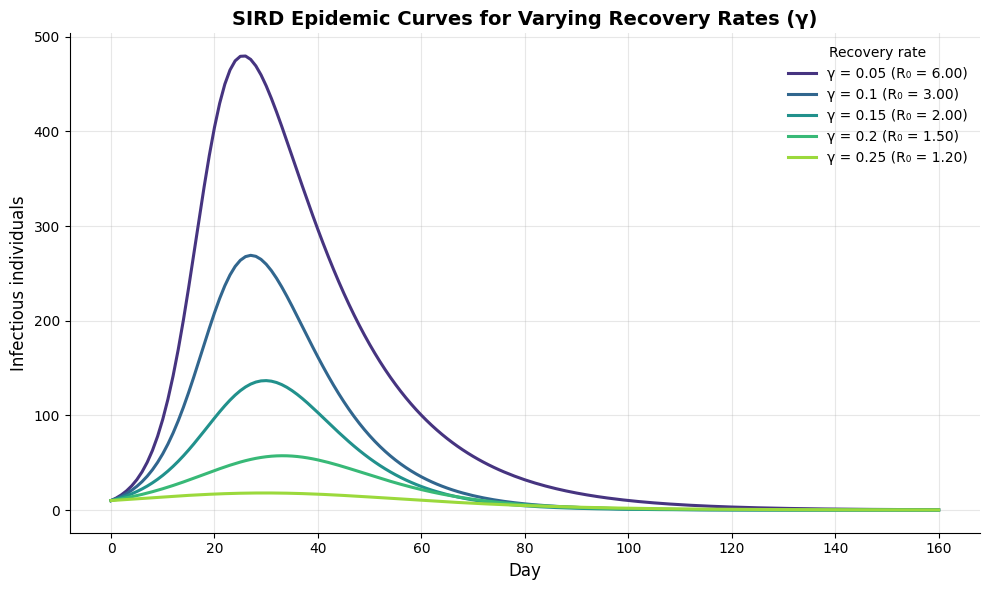

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,479.7,26.0,165.5
1,0.10,3.0,269.1,27.0,83.6
2,0.15,2.0,136.8,30.0,47.7
3,0.20,1.5,57.4,33.0,26.0
4,0.25,1.2,18.0,30.0,11.5


In [3]:
def run_gamma_sensitivity_analysis(gamma_values, beta=0.3, mu=0.01,
                                    S0=990, I0=10, R0_init=0, D0=0, days=160):
    """
    Run the SIRD model for each recovery rate in gamma_values and summarize
    the epidemic outcomes.

    Returns
    -------
    results_df : pandas.DataFrame
        Columns: ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths']
    fig : matplotlib.figure.Figure
        Epidemic curves (infectious individuals over time) for every gamma.
    """
    y0 = (S0, I0, R0_init, D0) # Initial conditions: S, I, R, D
    t = np.linspace(0, days, days + 1)

    records = [] # Store results for each gamma
    curves = {} # Store infectious curves for plotting

    for gamma in gamma_values:
        # Solve SIRD model for current gamma
        solution = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = solution.T

        # Find peak infection metrics
        peak_idx = np.argmax(I)
        records.append({
            'gamma': gamma,
            'R0': beta / gamma,
            'peak_infected': I[peak_idx],
            'peak_day': t[peak_idx],
            'total_deaths': D[-1],
        })
        curves[gamma] = I

    results_df = pd.DataFrame(records, columns=['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths'])
    results_df = results_df.round({'gamma': 2, 'R0': 2, 'peak_infected': 1, 'peak_day': 0, 'total_deaths': 1})

    # --- Publication-quality plot ---
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(gamma_values)))

    for color, gamma in zip(colors, gamma_values):
        ax.plot(t, curves[gamma], color=color, linewidth=2.2,
                label=f'γ = {gamma} (R₀ = {beta / gamma:.2f})')

    ax.set_xlabel('Day', fontsize=12)
    ax.set_ylabel('Infectious individuals', fontsize=12)
    ax.set_title('SIRD Epidemic Curves for Varying Recovery Rates (γ)', fontsize=14, fontweight='bold')
    ax.legend(title='Recovery rate', frameon=False, fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    return results_df, fig


def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    This is the entry point required by the assignment brief. It fixes the set of
    recovery rates to be tested and delegates the integration and plotting to
    run_gamma_sensitivity_analysis above.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate, with columns
        ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths'].

    Side effects
    ------------
    Displays a publication-quality figure of the infectious curves for every
    recovery rate tested.
    """
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]

    # The whole population starts susceptible apart from the initial infections,
    # so S0 = N - I0 and both R and D start empty.
    results_df, fig = run_gamma_sensitivity_analysis(
        gamma_values, beta=beta, mu=mu,
        S0=N - I0, I0=I0, R0_init=0, D0=0, days=simulation_days
    )

    plt.show()
    return results_df


# Run the sensitivity analysis across the required recovery rates.
# gamma_values is kept at module level because Parts 2 and 3 reuse it.
gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]
results_df = analyze_recovery_rates(beta=0.3, mu=0.01, N=1000, I0=10, simulation_days=160)
results_df

High transmission results:


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.6,21.0,284.8
1,0.10,4.00,340.1,22.0,159.9
2,0.15,2.67,213.5,24.0,102.6
3,0.20,2.00,123.9,27.0,67.4
4,0.25,1.60,63.1,30.0,42.7


Low transmission results:


,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.4,44.0,88.2
1,0.10,2.00,139.3,52.0,36.7
2,0.15,1.33,31.3,67.0,13.6
3,0.20,1.00,5.0,0.0,1.8
4,0.25,0.80,5.0,0.0,0.4


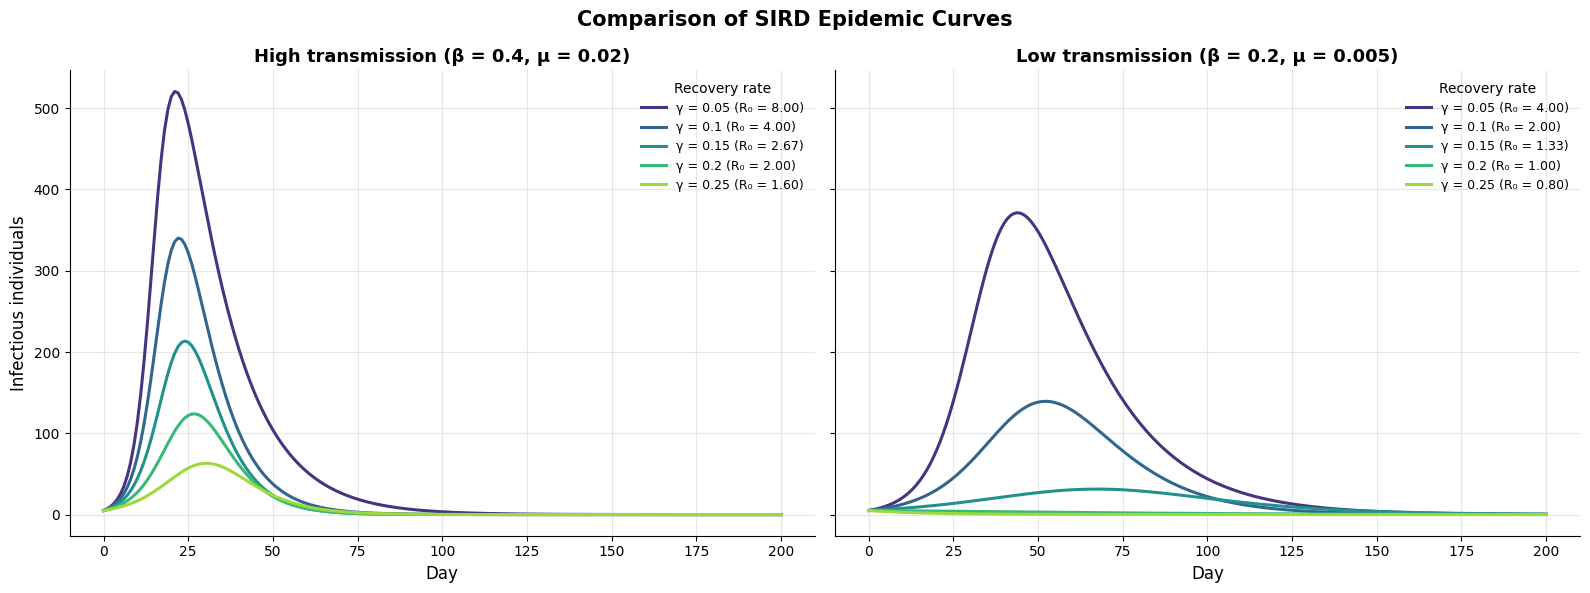

In [4]:
results_high_transmission, high_transmission_fig = run_gamma_sensitivity_analysis(
    gamma_values, beta=0.4, mu=0.02,
    S0=995, I0=5, R0_init=0, D0=0, days=200
)
results_low_transmission, low_transmission_fig = run_gamma_sensitivity_analysis(
    gamma_values, beta=0.2, mu=0.005,
    S0=995, I0=5, R0_init=0, D0=0, days=200
)

print('High transmission results:')
display(results_high_transmission)

print('Low transmission results:')
display(results_low_transmission)

# Compare both parameter scenarios using the curves generated above.
comparison_fig, comparison_axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
scenario_figures = [
    (high_transmission_fig, comparison_axes[0], 'High transmission (β = 0.4, μ = 0.02)'),
    (low_transmission_fig, comparison_axes[1], 'Low transmission (β = 0.2, μ = 0.005)'),
]

for source_fig, axis, title in scenario_figures:
    for source_line in source_fig.axes[0].lines:
        axis.plot(
            source_line.get_xdata(), source_line.get_ydata(),
            color=source_line.get_color(), linewidth=2.2,
            label=source_line.get_label()
        )
    axis.set_title(title, fontsize=13, fontweight='bold')
    axis.set_xlabel('Day', fontsize=12)
    axis.grid(alpha=0.3)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(title='Recovery rate', frameon=False, fontsize=9)

plt.close(high_transmission_fig)
plt.close(low_transmission_fig)

comparison_axes[0].set_ylabel('Infectious individuals', fontsize=12)
comparison_fig.suptitle('Comparison of SIRD Epidemic Curves', fontsize=15, fontweight='bold')
comparison_fig.tight_layout()
plt.show()

High transmission with high mortality rate is worse for public health, as the peak of infection is considerably higher for the same rate of recovery, and also the total deaths at the end are a lot more. In addition, with a higher transmission rate, the basic reproduction number becomes higher as well, so more people become sick at the same time. This puts considerable preassure on medical facilities, as hospitals get full and staff and available treatment fall short. In contrast, when the infection is more spread out time-wise, like it is for low transmission, not as many people need medical attention at the same time, so occurences like not enough available space for everyone sick in the hospitals is a lot more rare. Therefore, the high transmission scenario poses a significantly bigger threat to public health.

## Part 3: Policy recommendations

The two scenario tables above summarise *what* happens as the recovery rate changes. This
section asks *why* it happens, how much a realistic treatment programme would be worth, and
which real intervention could deliver such a change.

Two quantities used throughout are not returned by the Part 1 function, so they are computed
in the cell below:

- **Epidemic duration** — the first day after the peak on which fewer than one individual is
  still infectious. This is an arbitrary but consistent stopping rule; the comparison between
  γ values is what matters, not the absolute value.
- **Case fatality ratio (CFR)** — deaths divided by the number ever infected. In this SIRD
  model an infectious individual leaves the I compartment towards R at rate γ and towards D
  at rate μ, so the CFR has the closed form μ / (γ + μ), independent of β and of the
  population size.

In [5]:
# --- Supporting calculations for Part 3 --------------------------------------
# The Part 1 function returns summary metrics only, so the model is re-solved here to
# recover the full trajectories and extract epidemic duration, the number ever infected,
# and the realised case fatality ratio.

def epidemic_profile(gamma, beta, mu, S0=995, I0=5, days=200):
    """
    Re-solve the SIRD model for one recovery rate and return extra outcome measures.

    Returns
    -------
    duration : float
        First day after the peak on which I(t) < 1 (NaN if the epidemic never falls below 1).
    ever_infected : float
        Total individuals who left the susceptible compartment over the simulation.
    cfr : float
        Realised case fatality ratio, deaths / ever infected.
    """
    t = np.linspace(0, days, days + 1)
    S, I, R, D = odeint(sird_model, (S0, I0, 0, 0), t, args=(beta, gamma, mu)).T

    peak_idx = int(np.argmax(I))
    past_peak_and_small = np.where((t > t[peak_idx]) & (I < 1))[0]
    duration = t[past_peak_and_small[0]] if past_peak_and_small.size else np.nan

    ever_infected = (S0 + I0) - S[-1]
    return duration, ever_infected, D[-1] / ever_infected


def add_part3_columns(results, beta, mu):
    """Attach duration, ever-infected and CFR columns to a Part 1 / Part 2 results table."""
    enriched = results.copy()
    profiles = [epidemic_profile(g, beta, mu) for g in enriched['gamma']]
    enriched['duration_days'] = [p[0] for p in profiles]
    enriched['ever_infected'] = np.round([p[1] for p in profiles], 1)
    enriched['CFR_percent'] = np.round([100 * p[2] for p in profiles], 1)
    return enriched


detail_high = add_part3_columns(results_high_transmission, beta=0.4, mu=0.02)
detail_low = add_part3_columns(results_low_transmission, beta=0.2, mu=0.005)

print('Scenario A - high transmission (beta = 0.4, mu = 0.02)')
display(detail_high)
print('Scenario B - low transmission (beta = 0.2, mu = 0.005)')
display(detail_low)

Scenario A - high transmission (beta = 0.4, mu = 0.02)


,gamma,R0,peak_infected,peak_day,total_deaths,duration_days,ever_infected,CFR_percent
0,0.05,8.00,520.6,21.0,284.8,118.0,996.7,28.6
1,0.10,4.00,340.1,22.0,159.9,86.0,959.4,16.7
2,0.15,2.67,213.5,24.0,102.6,77.0,872.2,11.8
3,0.20,2.00,123.9,27.0,67.4,78.0,741.7,9.1
4,0.25,1.60,63.1,30.0,42.7,84.0,576.4,7.4


Scenario B - low transmission (beta = 0.2, mu = 0.005)


,gamma,R0,peak_infected,peak_day,total_deaths,duration_days,ever_infected,CFR_percent
0,0.05,4.00,371.4,44.0,88.2,178.0,970.8,9.1
1,0.10,2.00,139.3,52.0,36.7,154.0,770.8,4.8
2,0.15,1.33,31.3,67.0,13.6,185.0,423.5,3.2
3,0.20,1.00,5.0,0.0,1.8,116.0,75.3,2.4
4,0.25,0.80,5.0,0.0,0.4,28.0,22.1,2.0


### 3.1 Parameter impact analysis

Raising the recovery rate improves every outcome measure except epidemic duration, which
behaves non-monotonically. The three effects have different sizes and different causes.

**Peak infections fall faster than proportionally.** In Scenario A a fivefold increase in γ,
from 0.05 to 0.25, cuts the peak from 520.6 to 63.1 infectious individuals — an 88%
reduction. Halving the peak does not require halving R₀: γ = 0.05 → 0.10 (R₀ 8 → 4) removes
180 cases from the peak, while γ = 0.20 → 0.25 (R₀ 2.0 → 1.6) removes only 61, but the
*relative* reduction grows from 35% to 49%. The peak prevalence of an SIR-type model
collapses towards zero as R₀ approaches 1, so each additional unit of recovery rate is worth
progressively more in proportional terms. Scenario B shows the endpoint of that behaviour:
between γ = 0.15 and γ = 0.20 the peak drops from 31.3 to 5.0, and 5.0 is simply the initial
seed. No outbreak occurs at all.

**Total deaths fall for two compounding reasons.** Deaths are the product of how many people
are ever infected and the fraction of infections that end in death, and γ shrinks both. In
Scenario A at γ = 0.05 the CFR is 0.02 / 0.07 = 28.6% and 996.7 of 1000 people are
infected, giving 284.8 deaths. At γ = 0.25 the CFR is 0.02 / 0.27 = 7.4% and only 576.4 people
are infected, giving 42.7 deaths. The 85% fall in deaths decomposes into a 74% fall in CFR and a
42% fall in the number infected — the two multiply, which is why deaths respond more strongly
to γ than either factor alone. Scenario B is milder on both counts (μ is four times smaller
and β is halved) and its death toll spans 88.2 down to 0.4.

**Duration is not monotonic, and is the wrong policy target.** In Scenario A the epidemic
ends on day 118, 86, 77, 78 and 84 for γ = 0.05 … 0.25. Faster recovery shortens the epidemic
while R₀ remains comfortably above 1, because the outbreak burns through the susceptible pool
sooner. Past roughly γ = 0.15 the trend reverses: as R₀ falls towards 1 the epidemic grows
slowly and leaves a long, flat tail, so the *mildest* epidemic in Scenario A is not the
shortest one. A policy judged on "how long the outbreak lasts" would therefore rank γ = 0.15
above γ = 0.25, even though the latter causes 60% fewer deaths.

**A note on R₀ = β/γ.** The assignment defines R₀ = β/γ, which ignores death as a second route
out of the infectious compartment. The reproduction number implied by the model equations is
β / (γ + μ). The difference is visible in Scenario B at γ = 0.20: β/γ = 1.00 suggests a
knife-edge, but β/(γ + μ) = 0.2 / 0.205 = 0.98 < 1, and the simulation correctly produces no
outbreak. The tabulated R₀ column is therefore a slight overestimate of transmissibility,
by a factor of (γ + μ)/γ — 8% in Scenario A at γ = 0.25, 2.5% in Scenario B.

Effect of a 50% increase in recovery rate (Scenario A baseline)


,gamma_baseline,gamma_treated,deaths_baseline,deaths_treated,peak_baseline,peak_treated,deaths_averted,deaths_reduction_percent,peak_reduction_percent
0,0.05,0.075,284.8,207.2,520.6,421.8,77.6,27.2,19.0
1,0.10,0.150,159.9,102.6,340.1,213.5,57.3,35.8,37.2
2,0.15,0.225,102.6,54.1,213.5,90.3,48.5,47.3,57.7
3,0.20,0.300,67.4,24.1,123.9,25.5,43.3,64.2,79.4
4,0.25,0.375,42.7,5.5,63.1,5.0,37.2,87.1,92.1


No treatment (0% coverage):   159.9 deaths
30% coverage:                 139.0 deaths (13.1% reduction)
Full coverage (100%):         102.6 deaths (35.8% reduction)


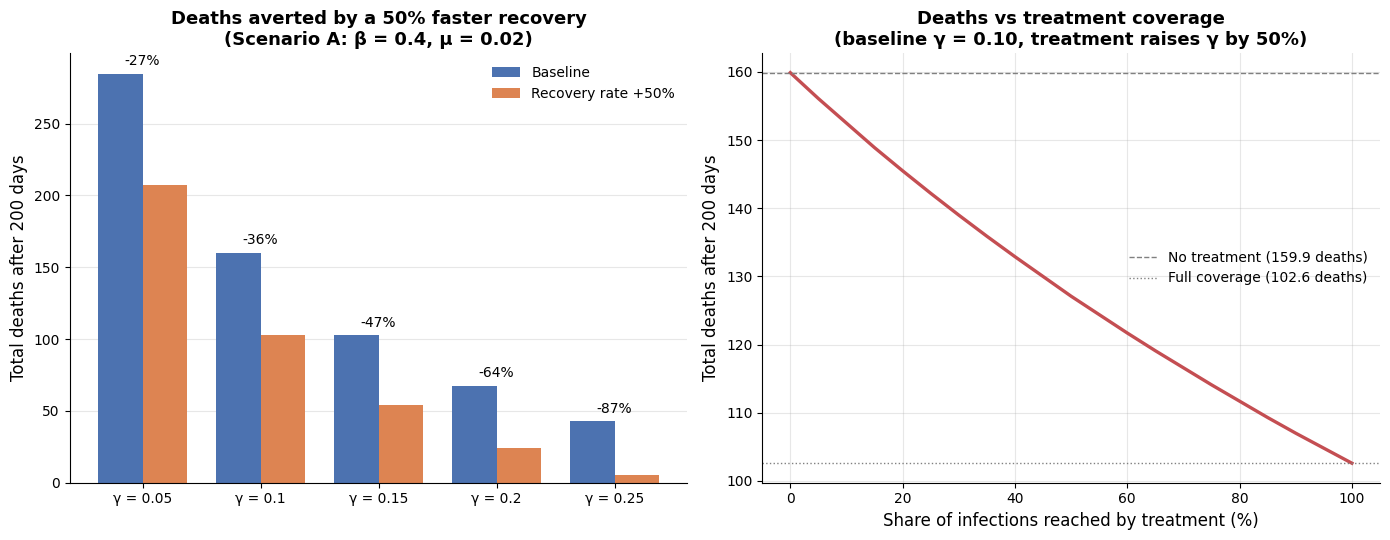

In [6]:
# --- Part 3.2: an intervention that raises the recovery rate by 50% ----------
# Baseline is Scenario A (beta = 0.4, mu = 0.02, N = 1000, I0 = 5, 200 days).
# The intervention maps every recovery rate gamma to 1.5 * gamma.

BOOST = 1.5

treated_results, treated_fig = run_gamma_sensitivity_analysis(
    [BOOST * g for g in gamma_values], beta=0.4, mu=0.02,
    S0=995, I0=5, R0_init=0, D0=0, days=200
)
plt.close(treated_fig)  # the curves are re-plotted below in a comparison figure

intervention = pd.DataFrame({
    'gamma_baseline': gamma_values,
    'gamma_treated': [BOOST * g for g in gamma_values],
    'deaths_baseline': results_high_transmission['total_deaths'].values,
    'deaths_treated': treated_results['total_deaths'].values,
    'peak_baseline': results_high_transmission['peak_infected'].values,
    'peak_treated': treated_results['peak_infected'].values,
})
intervention['deaths_averted'] = intervention['deaths_baseline'] - intervention['deaths_treated']
intervention['deaths_reduction_percent'] = (
    100 * intervention['deaths_averted'] / intervention['deaths_baseline']
)
intervention['peak_reduction_percent'] = (
    100 * (intervention['peak_baseline'] - intervention['peak_treated'])
    / intervention['peak_baseline']
)
intervention = intervention.round({
    'gamma_baseline': 3, 'gamma_treated': 3,
    'deaths_baseline': 1, 'deaths_treated': 1,
    'peak_baseline': 1, 'peak_treated': 1,
    'deaths_averted': 1, 'deaths_reduction_percent': 1, 'peak_reduction_percent': 1,
})

print('Effect of a 50% increase in recovery rate (Scenario A baseline)')
display(intervention)

# --- Coverage sensitivity ----------------------------------------------------
# A treatment only raises the population-average recovery rate for the fraction of
# infections it actually reaches. With coverage c, the effective rate is gamma * (1 + 0.5c).
BASELINE_GAMMA = 0.10
coverage = np.linspace(0, 1, 21)
coverage_deaths = []
for c in coverage:
    df_c, fig_c = run_gamma_sensitivity_analysis(
        [BASELINE_GAMMA * (1 + 0.5 * c)], beta=0.4, mu=0.02,
        S0=995, I0=5, R0_init=0, D0=0, days=200
    )
    plt.close(fig_c)  # close immediately, the loop only needs the summary number
    coverage_deaths.append(df_c['total_deaths'].iloc[0])

print(f'No treatment (0% coverage):   {coverage_deaths[0]:.1f} deaths')
print(f'30% coverage:                 {coverage_deaths[6]:.1f} deaths '
      f'({100 * (coverage_deaths[0] - coverage_deaths[6]) / coverage_deaths[0]:.1f}% reduction)')
print(f'Full coverage (100%):         {coverage_deaths[-1]:.1f} deaths '
      f'({100 * (coverage_deaths[0] - coverage_deaths[-1]) / coverage_deaths[0]:.1f}% reduction)')

# --- Figure: deaths under baseline vs intervention, and the coverage curve ----
fig, (ax_bar, ax_cov) = plt.subplots(1, 2, figsize=(14, 5.5))

bar_positions = np.arange(len(gamma_values))
bar_width = 0.38
ax_bar.bar(bar_positions - bar_width / 2, intervention['deaths_baseline'],
           bar_width, label='Baseline', color='#4C72B0')
ax_bar.bar(bar_positions + bar_width / 2, intervention['deaths_treated'],
           bar_width, label='Recovery rate +50%', color='#DD8452')
for x, (base, treat) in enumerate(zip(intervention['deaths_baseline'],
                                      intervention['deaths_treated'])):
    ax_bar.text(x, max(base, treat) + 6, f'-{100 * (base - treat) / base:.0f}%',
                ha='center', fontsize=10)
ax_bar.set_xticks(bar_positions)
ax_bar.set_xticklabels([f'γ = {g}' for g in gamma_values])
ax_bar.set_ylabel('Total deaths after 200 days', fontsize=12)
ax_bar.set_title('Deaths averted by a 50% faster recovery\n(Scenario A: β = 0.4, μ = 0.02)',
                 fontsize=13, fontweight='bold')
ax_bar.legend(frameon=False, fontsize=10)
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.set_axisbelow(True)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

ax_cov.plot(100 * coverage, coverage_deaths, color='#C44E52', linewidth=2.4)
ax_cov.axhline(coverage_deaths[0], color='grey', linestyle='--', linewidth=1,
               label=f'No treatment ({coverage_deaths[0]:.1f} deaths)')
ax_cov.axhline(coverage_deaths[-1], color='grey', linestyle=':', linewidth=1,
               label=f'Full coverage ({coverage_deaths[-1]:.1f} deaths)')
ax_cov.set_xlabel('Share of infections reached by treatment (%)', fontsize=12)
ax_cov.set_ylabel('Total deaths after 200 days', fontsize=12)
ax_cov.set_title('Deaths vs treatment coverage\n(baseline γ = 0.10, treatment raises γ by 50%)',
                 fontsize=13, fontweight='bold')
ax_cov.legend(frameon=False, fontsize=10)
ax_cov.grid(alpha=0.3)
ax_cov.spines['top'].set_visible(False)
ax_cov.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

### 3.2 Intervention analysis

**Headline result.** Taking Scenario A with γ = 0.10 as the baseline — R₀ = 4, a plausible
central estimate for a respiratory pathogen — an intervention that raises the recovery rate
by 50% to γ = 0.15 reduces total deaths from 159.9 to 102.6 per 1000 people. That is
**57.3 deaths averted, a 35.8% reduction**, together with a fall in the peak from 340.1 to
213.5 infectious individuals (−37.2%), which also relieves pressure on hospital capacity.

**Where the 35.8% comes from.** The two multiplicative factors identified in 3.1 both move:

| Factor | Baseline (γ = 0.10) | Treated (γ = 0.15) | Change |
|---|---|---|---|
| Case fatality ratio, μ/(γ+μ) | 0.02/0.12 = 16.7% | 0.02/0.17 = 11.8% | ×0.71 |
| Ever infected | 959.4 | 872.2 | ×0.91 |
| Deaths | 159.9 | 102.6 | ×0.64 |

0.71 × 0.91 = 0.64, so a 35.8% reduction. Roughly three-quarters of the benefit comes from
patients surviving an infection they would otherwise have died from, and one-quarter from
infections that never happen because infectious people are removed sooner.

**The benefit depends strongly on where you start.** The table produced above shows the same
+50% intervention applied at every baseline recovery rate:

| Baseline γ | Treated γ | Deaths before | Deaths after | Reduction |
|---|---|---|---|---|
| 0.05 | 0.075 | 284.8 | 207.2 | 27.2% |
| 0.10 | 0.15 | 159.9 | 102.6 | 35.8% |
| 0.15 | 0.225 | 102.6 | 54.1 | 47.3% |
| 0.20 | 0.30 | 67.4 | 24.1 | 64.3% |
| 0.25 | 0.375 | 42.7 | 5.5 | 87.1% |

The proportional benefit more than triples across the range, even though the intervention is
identical. The reason is the R₀ = 1 threshold: at a baseline of γ = 0.25 the boost pushes
β/(γ+μ) from 1.48 to 1.07, close enough to 1 that the outbreak barely propagates. **The policy
implication is that treatment and transmission control are strongly complementary, not
additive.** A treatment programme is worth far more when it is paired with measures that have
already brought R₀ close to 1 — the same 57 deaths averted at γ = 0.10 becomes 37 deaths
averted at γ = 0.25, but out of a much smaller baseline, meaning almost the entire remaining
burden is eliminated.

**Coverage caveat.** The 50% figure assumes every infection is treated. If treatment reaches
only a fraction *c* of infections, the population-average recovery rate rises to γ(1 + 0.5c).
At 30% coverage the model gives 139.0 deaths instead of 159.9 — a 13.1% reduction, roughly a
third of the idealised benefit. The coverage curve above is close to linear over this range,
so as a rule of thumb the realised benefit scales with the share of cases reached.

### 3.3 Real-world application

**Intervention: antiviral therapy, specifically remdesivir for hospitalised COVID-19.**

*Mechanism.* Remdesivir is a nucleoside analogue prodrug. Once metabolised to its active
triphosphate form it is accepted by the SARS-CoV-2 RNA-dependent RNA polymerase as a
substitute for ATP and incorporated into the growing viral RNA strand, where it causes
delayed chain termination a few nucleotides later. Viral replication slows, peak viral load
falls, and the patient clears the infection sooner. In SIRD terms this is exactly an increase
in γ: individuals spend less time in the infectious compartment, and because the competing
exit rate μ is unchanged, a larger share of them exit through R rather than D.

*Realistic effectiveness.* In ACTT-1 (Beigel et al., *NEJM* 2020, 1062 hospitalised patients)
the median time to recovery was **10 days on remdesivir versus 15 days on placebo**. Reading
the mean infectious period as 1/γ, that corresponds to γ rising from 1/15 = 0.067 to
1/10 = 0.100 — **a 50% increase**, the exact magnitude modelled in 3.2. Mortality by day 29
was 11% versus 15%, a difference the trial could not distinguish from chance.

*Three reasons the modelled benefit is an upper bound.*

1. The evidence is not unanimous. The WHO Solidarity trial, with roughly 11,000 patients,
   found no significant effect of remdesivir on mortality, ventilation, or duration of
   hospital stay. A 50% increase in γ should be read as an optimistic reading of a contested
   literature, not a settled effect size.
2. The model's γ is the rate of leaving *infectiousness*, whereas the trial measured
   *clinical* recovery. Hospitalised COVID-19 patients are typically several days past their
   peak of viral shedding, so shortening their clinical course removes less transmission than
   the model assumes. The mortality benefit transfers to the model more faithfully than the
   transmission benefit does.
3. Remdesivir is an intravenous drug given to hospitalised patients, so coverage of all
   infections is far below 100%. Applying the coverage calculation from 3.2, treating the
   ~5% of infections that reach hospital would raise the population-average γ by about 2.5%,
   not 50%.

*A better-matched comparator.* For a community-treated pathogen, oseltamivir for influenza is
the closer analogue: it shortens symptom duration by roughly 0.5–1 day out of 5–6, a 10–20%
increase in γ. That is a far smaller effect than the 50% modelled here, but it can be
delivered to a much larger share of cases — and 3.2 shows that a modest boost with wide
coverage and a small boost with narrow coverage are not equivalent, because only the former
moves the population-average γ appreciably.

## Conclusions

The recovery rate is a powerful lever in the SIRD model, and it acts through two channels at
once. Because deaths equal the number ever infected multiplied by μ/(γ + μ), any increase in γ
shrinks both factors simultaneously, which is why a fivefold increase in γ cuts Scenario A's
death toll by 85% (284.8 to 42.7 per 1000) while cutting the peak by 88% (520.6 to 63.1).

Scenario A is unambiguously worse for public health than Scenario B at every recovery rate
tested: at γ = 0.10 it produces 159.9 deaths against 36.7, and a peak of 340.1 against 139.3.
The gap comes from both parameters — the higher β infects more people, and the four-times
higher μ kills a larger share of them.

Epidemic duration is the one outcome that does not improve monotonically, peaking in
*shortness* around γ = 0.15 in Scenario A and lengthening again as R₀ approaches 1. Policies
should therefore be evaluated on deaths and peak burden, not on how quickly the outbreak is
declared over.

A treatment that raises recovery rates by 50% averts 57.3 deaths per 1000 at the γ = 0.10
baseline (−35.8%), but the same intervention averts 87% of deaths when applied to an epidemic
already pushed near the R₀ = 1 threshold. The practical conclusion is that treatment is worth
most when combined with transmission control, and that its real-world value is governed as
much by how many infections it reaches as by how well it works in the patients who receive it.